# KS 风险指标

计算并可视化 KS 指标评估模型区分度的 Python 实现。

In [216]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import os, re, sys
%matplotlib inline
## 设置属性防止中文乱码
plt.rcParams['font.sans-serif'] = [u'SimHei']
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings("ignore")

In [217]:
import matplotlib as mpl
print('pandas:%s'%(pd.__version__))
print('numpy:%s'%(np.__version__))
print('matplotlib:%s'%(mpl.__version__))
print('seaborn:%s'%(sns.__version__))

pandas:2.0.0
numpy:1.23.5
matplotlib:3.7.1
seaborn:0.12.2


## 0.读取数据

In [218]:
df = pd.read_excel('ks_score_sample.xlsx')
df.shape

(10000, 2)

In [219]:
df.target.value_counts()

target
0    9500
1     500
Name: count, dtype: int64

## 1.KS风险指标计算

### 1.1.手动实现

In [220]:
# 等频分箱
n = 10
df_bin=pd.qcut(df['xgb_score'],n)
group_all=df['target'].groupby(df_bin).count()
group_bad=df['target'].groupby(df_bin).sum()
group_good=group_all-group_bad    
var_bin=pd.DataFrame()
var_bin['sum']=group_all
var_bin['bad_count']=group_bad
var_bin['good_count']=group_good

var_bin['badpct']=var_bin['bad_count']/var_bin['bad_count'].sum()
var_bin['goodpct']=var_bin['good_count']/var_bin['good_count'].sum()
var_bin['cum_badpct'] = var_bin['badpct'].cumsum()
var_bin['cum_goodpct'] = var_bin['goodpct'].cumsum()
var_bin['ks'] = round(abs(var_bin['cum_badpct']-var_bin['cum_goodpct']),4)

In [222]:
var_bin.style.bar(subset=['ks'], color='orange', width=80, height=80, align='left', vmin=0)

,sum,bad_count,good_count,badpct,goodpct,cum_badpct,cum_goodpct,ks
xgb_score,,,,,,,,
"(205.38899999999998, 448.898]",1000,150,850,0.300000,0.089474,0.300000,0.089474,0.210500
"(448.898, 483.828]",1000,100,900,0.200000,0.094737,0.500000,0.184211,0.315800
"(483.828, 508.842]",1000,70,930,0.140000,0.097895,0.640000,0.282105,0.357900
"(508.842, 530.35]",1001,50,951,0.100000,0.100105,0.740000,0.382211,0.357800
"(530.35, 550.93]",1001,45,956,0.090000,0.100632,0.830000,0.482842,0.347200
"(550.93, 570.996]",998,35,963,0.070000,0.101368,0.900000,0.584211,0.315800
"(570.996, 592.425]",1000,20,980,0.040000,0.103158,0.940000,0.687368,0.252600
"(592.425, 618.716]",1000,15,985,0.030000,0.103684,0.970000,0.791053,0.178900
"(618.716, 654.116]",1000,10,990,0.020000,0.104211,0.990000,0.895263,0.094700


In [223]:
max(var_bin['ks'])

0.3579

### 1.2.sklearn实现

In [226]:
from sklearn import metrics
fpr, tpr, thres = metrics.roc_curve(df['target'], df['xgb_score'], pos_label=1)
ks = np.max(np.abs(tpr - fpr))
print(round(ks,4))

0.3717


### 1.3.好坏分布

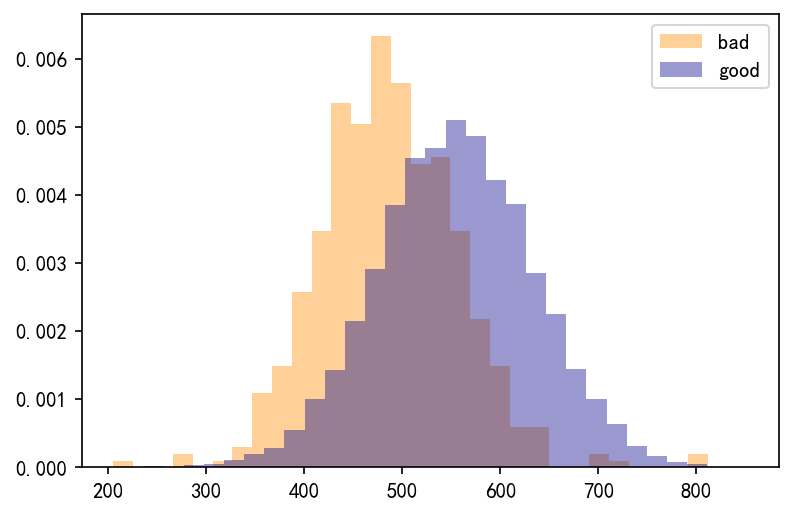

In [228]:
df_bad  = df.loc[df['target']==1,'xgb_score']
df_good = df.loc[df['target']==0,'xgb_score']
fig = plt.figure(dpi=150)
plt.hist(df_bad,  bins=30, alpha=0.4, color='darkorange', density=True, label='bad')
plt.hist(df_good, bins=30, alpha=0.4, color='darkblue', density=True, label='good')
plt.legend(['bad', 'good'])
plt.show()

## 2.KS可视化

In [229]:
########################## KSplot ############################# 
def ks_simple_plot(data, y, x):
    from sklearn import metrics
    fpr, tpr, thres = metrics.roc_curve(data[y], data[x], pos_label=1)
    ks = abs(tpr[1:]-fpr[1:])
    max_thres = thres[np.argmax(ks)]
    fig = plt.figure(dpi=150)
    plt.plot(thres[1:], tpr[1:], 'go--', linewidth=1, markersize=1)
    plt.plot(thres[1:], fpr[1:], 'ro--', linewidth=1, markersize=1)
    plt.plot(thres[1:], ks, color='blue', linewidth=1, markersize=2)
    plt.axvline(max_thres, color='grey', linestyle='--', linewidth=0.8, label='cutoff')
    plt.axhline(max(ks), color='grey', linestyle='--', linewidth=0.8, label='max_ks')
    plt.text(x=max_thres, y =max(ks), s=('('+str(max_thres)+','+str(round(max(ks),4))+')'), fontsize=8)
    plt.xlabel('threshold')
    plt.legend(['累计坏占比', '累计好占比', 'KS'])
    plt.gca().invert_xaxis() 
    plt.show()

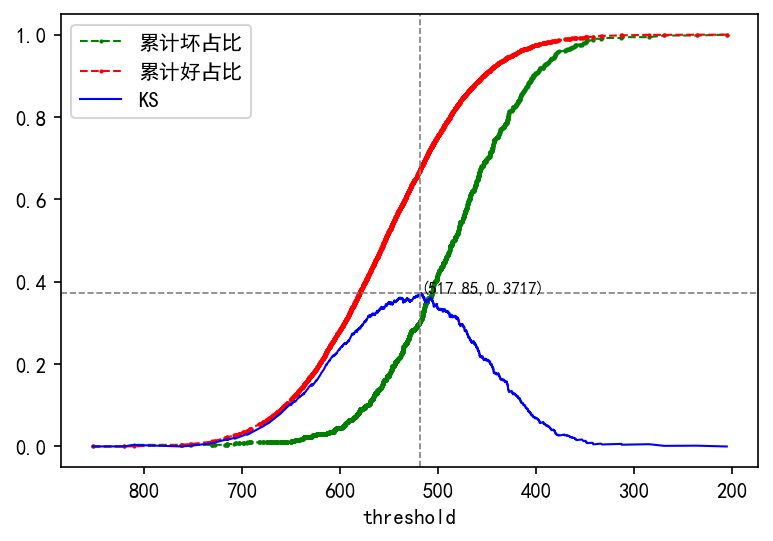

In [230]:
ks_simple_plot(df,'target','xgb_score')

## 3.番外

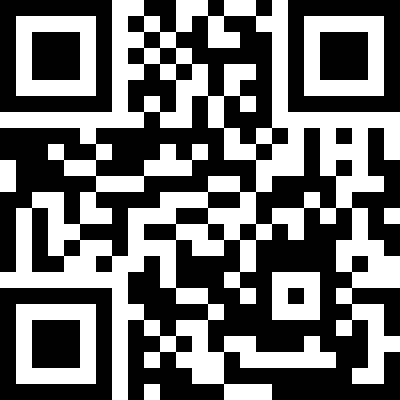